# Gate-Sequence Optimization: A Tutorial

`gkp_optimal_control.gate_optimization` optimizes the *parameters of a fixed-depth circuit* rather than a time-domain control pulse. The gates are treated as ideal unitaries: no Kerr, no finite pulse duration, no dispersive phase accumulation. The result is therefore an *upper* bound on what a real circuit of that depth achieves, and a useful decoupling of circuit expressivity from pulse-level imperfection.

This notebook walks through the module end to end: displacement construction, a first small optimization, the anatomy of a result, the two gate sets, convergence diagnostics, layer-by-layer Wigner functions, warm starts, and finally optimizing a *gate* on the logical subspace rather than a single state.

## The two ansaetze

**ECD + qubit rotations** (Eickbusch *et al.*, *Nat. Phys.* **18**, 1464 (2022)) uses a transmon ancilla dispersively coupled to the cavity:

$$U = R(\theta_{N+1}, \phi_{N+1}) \prod_{i=N}^{1} \mathrm{ECD}(\beta_i)\, R(\theta_i, \phi_i),$$

$$\mathrm{ECD}(\beta) = D(\beta/2)\,\ket{e}\bra{g} + D(-\beta/2)\,\ket{g}\bra{e}, \qquad R(\theta,\phi) = \exp\!\left[-\tfrac{i\theta}{2}\left(\sigma_x\cos\phi + \sigma_y\sin\phi\right)\right].$$

The qubit is never represented explicitly. Since both ECD and $R$ are $2\times 2$ block operators on the qubit index, the state is carried as a *pair* of cavity kets $(\psi_g, \psi_e)$, which halves the memory and the cost of every displacement relative to a $2 n_{\text{fock}}$ joint space. With $N$ ECDs there are $N+1$ rotations and $4N + 2$ real parameters.

**SNAP + displacements** (Heeres *et al.*, *PRL* **115**, 137002 (2015)) acts on the cavity alone:

$$U = D(\alpha_{N+1}) \prod_{i=N}^{1} S(\vec\theta_i)\, D(\alpha_i), \qquad S(\vec\theta) = \sum_n e^{i\theta_n}\ket{n}\bra{n},$$

with $N$ SNAPs, $N+1$ displacements, and $N n_{\text{snap}} + 2(N+1)$ parameters.

In both cases `n_gates` counts ECDs or SNAPs — not the total gate count.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import jax

jax.config.update("jax_enable_x64", True)  # before any array is created

import jax.numpy as jnp
import jaxquantum as jqt
import matplotlib.pyplot as plt

from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    make_displacement,
    optimize_gate_sequence,
    sequence_history,
)
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import cat_states, gkp_states

set_plot_style()

The `jax.config.update` call has to come *before* any array is created, which is why it sits between the two imports above rather than at the bottom of the cell. In FP32 the fidelity plateaus around $1 - 10^{-6}$ and the optimizer will chase numerical noise past that; `optimize_gate_sequence` emits a `RuntimeWarning` if x64 is off.

Everything below stays in `jax.numpy`. Matplotlib accepts JAX arrays directly (it calls `__array__` on them), so no host conversion is needed for plotting; the only `float()` casts are where a Python scalar is wanted for an f-string.

## A note on state types

The state constructors in this package are not uniform about their return type. `gkp_states` normalizes with the `Qarray` *method* `.unit()` and returns `Qarray` objects, but `cat_states` uses the *function* `jqt.unit(...)`, which in this version of `jaxquantum` drops the wrapper and hands back a bare `jaxlib` array. So `gkp_0.data` works and `even_cat.data` raises `AttributeError`.

`optimize_gate_sequence` does not care — it coerces both. The plotting helpers do care, since they call `jqt.wigner`. The two helpers below smooth this over, and are worth defining once at the top of any notebook in this project.

(The underlying fix, if you want it, is to change `cat_states` to `return even_cat.unit(), odd_cat.unit()` in `states.py`.)

In [2]:
def ket(state):
    """Qarray or bare array -> flat, normalized jnp Fock-amplitude vector."""
    data = state.data if hasattr(state, "data") else state
    amps = jnp.asarray(data).reshape(-1)
    return amps / jnp.linalg.norm(amps)


def as_qarray(state):
    """Qarray or bare array -> normalized Qarray ket, ready for plot_wigner."""
    return jqt.Qarray.create(ket(state).reshape(-1, 1))

## Displacement operators

Every gate in both ansaetze is built from $D(\alpha)$, so the way $D$ is constructed sets both the accuracy and the speed of the whole optimization. `make_displacement` returns a jittable `alpha -> D(alpha)` closure with two available methods:

| `disp_method` | Construction | Notes |
|---|---|---|
| `"expm"` (default) | $\exp(\alpha a^\dagger - \alpha^* a)$ of the truncated generator | exactly unitary; gradients flow through an `expm` Frechet derivative |
| `"quadrature"` | BCH form $e^{-i x_0 p_0} e^{i\sqrt{2} p_0 \hat x} e^{-i\sqrt{2} x_0 \hat p}$ with $\hat x, \hat p$ eigendecomposed once | exactly unitary, same accuracy, roughly 4x faster; gradients flow through a diagonal exponential |

A third option — assembling $\bra{m} D(\alpha) \ket{n}$ from the closed-form matrix elements — is deliberately *not* offered. Those are the exact infinite-dimensional elements restricted to a truncated block, so the matrix is not unitary ($\lVert D^\dagger D - I \rVert \approx 0.5$ at $n_{\text{fock}} = 40$), norm is not conserved, and an optimizer will happily exploit that to report fidelities it never achieved. Verify unitarity for yourself before trusting either method:

In [3]:
n_fock = 80
alpha_test = 1.0 + 0.5j

for method in ("expm", "quadrature"):
    d_op = make_displacement(n_fock, method)(alpha_test)
    unitarity_err = jnp.abs(d_op.conj().T @ d_op - jnp.eye(n_fock)).max()
    print(f"{method:>11}: ||D^dag D - I||_max = {float(unitarity_err):.2e}")

d_expm = make_displacement(n_fock, "expm")(alpha_test)
d_quad = make_displacement(n_fock, "quadrature")(alpha_test)
print(f"\nexpm vs quadrature: {float(jnp.abs(d_expm - d_quad).max()):.2e}")

       expm: ||D^dag D - I||_max = 1.55e-15
 quadrature: ||D^dag D - I||_max = 4.00e-15

expm vs quadrature: 5.80e-01


## Target states

Any ket the module can coerce works as an initial or target state: a `jaxquantum.Qarray`, a raw `(n_fock,)` or `(n_fock, 1)` array, a batched `(K, n_fock)` array, or a list of those. Everything is normalized internally, and `n_fock` is inferred if you do not pass it.

We set up a few targets of increasing difficulty: a Fock state, an even cat, and the finite-energy GKP logical $\ket{0_L}$.

In [4]:
gkp_delta = 0.4
gkp_cutoff = 5
gkp_alpha = jnp.sqrt(jnp.pi / 2)
gkp_beta = 1j * jnp.sqrt(jnp.pi / 2)

vac = jqt.basis(n_fock, 0)
fock_3 = jqt.basis(n_fock, 3)
even_cat, _ = cat_states(n_fock, 2.0)
gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)

ns = jnp.arange(n_fock)
for label, state in [("|3>", fock_3), ("even cat", even_cat), ("|0_L>", gkp_0)]:
    probs = jnp.abs(ket(state)) ** 2
    n_bar = jnp.sum(ns * probs)
    tail = jnp.sum(probs[-8:])
    print(f"{label:>9}:  n_bar = {float(n_bar):6.2f}   top-8 Fock population = {float(tail):.2e}")

      |3>:  n_bar =   3.00   top-8 Fock population = 0.00e+00
 even cat:  n_bar =   4.00   top-8 Fock population = 1.34e-62
    |0_L>:  n_bar =   3.30   top-8 Fock population = 4.10e-09


The top-of-truncation population matters twice over. A target with support at the truncation boundary is not representable, and — more subtly — *intermediate* states in the circuit are displaced further out than either endpoint, so a target that fits comfortably can still drive the optimizer into the boundary mid-circuit. That is what the leakage penalty below is for.

## A first optimization

The minimal call is `optimize_gate_sequence(gate_set, n_gates, psi_init, psi_targ)`. Everything after that is keyword-only. Here: prepare $\ket{3}$ from vacuum with four SNAP gates, keeping the run small so it finishes in seconds.

`n_snap=12` optimizes only the first twelve Fock phases per SNAP gate and pins the rest to zero — the physically honest choice, since the selective qubit pulses that implement SNAP only resolve low photon numbers. Leaving it `None` would optimize all `n_fock` phases and give the ansatz far more freedom than hardware has.

In [5]:
res_snap = optimize_gate_sequence(
    "snap+displacements",
    4,
    vac,
    fock_3,
    n_snap=12,
    loss_type="log_infidelity",
    optimizer=OptimizerConfig(n_seeds=6, n_adam_iters=600, seed=1),
)

gate set : snap   depth : 4   n_fock : 80
params   : 58   state pairs : 1   reduction : mean
loss     : log_infidelity   disp : expm   seeds : 6   n_snap : 12
--------------------------------------------------------------
Adam (600 iters x 6 seeds) in 91.7s
  seed fidelities: best 0.999994, median 0.999989, worst 0.999701
  best seed: 5
L-BFGS-B polish: 500 iters in 7.6s  ->  F = 0.999997
--------------------------------------------------------------
Final fidelity : 0.999997   (infidelity 2.595e-06)
Leakage        : 2.713e-33  (top 5 Fock levels)
Peak |disp|    : 1.658
Total time     : 100.4s


## Anatomy of a `GateOptResult`

`verbose=True` (the default) prints a running report; `summary()` reprints the headline numbers, and the object carries everything needed to reproduce or inspect the solution.

| Attribute | Contents |
|---|---|
| `fidelity`, `loss`, `leakage` | achieved $F$, final objective value (penalties included), population in the top `n_leak` levels |
| `params` | labelled dict — `thetas`/`phis`/`betas` for ECD, `snap_phases`/`alphas` for SNAP, plus `disp_magnitudes` and `per_pair_fidelity` |
| `flat_params` | the raw parameter vector, for warm starts |
| `final_states` | `(K, n_fock)` for SNAP, `(K, 2, n_fock)` for ECD (qubit block index second-to-last) |
| `per_seed_fidelity`, `best_seed` | multi-start spread and which seed won |
| `adam_history` | `(n_seeds, n_adam_iters)` loss trace |
| `polish_info` | L-BFGS-B iterations, success flag, fidelity before/after |
| `config` | every option used, which is what `sequence_history` reads back |

The array-valued fields come back as host `numpy` arrays, since they cross out of JAX at the end of the run — wrap them in `jnp.asarray` to keep working on device, as below. `final_qarray()` is the shortcut to a plottable state; for ECD it returns the $\ket{g}$ block renormalized.

In [6]:
print(res_snap.summary())
print()
print("params  :", {k: jnp.shape(v) for k, v in res_snap.params.items()})
print("polish  :", res_snap.polish_info)

alphas = jnp.asarray(res_snap.params["alphas"])
print("alphas  :", [f"{a:.3f}" for a in alphas])

gate set        : snap
n_gates         : 4
n_params        : 58
fidelity        : 0.999997
infidelity      : 2.595e-06
loss            : -1.286189e+01
leakage         : 2.713e-33
best seed       : 5 of 6
seed F spread   : 0.9997 .. 1.0000

params  : {'snap_phases': (4, 12), 'alphas': (5,), 'disp_magnitudes': (5,), 'per_pair_fidelity': (1,)}
polish  : {'nit': 500, 'success': False, 'message': 'STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT', 'fidelity_before': 0.9999943766073194, 'fidelity_after': 0.9999974049232346, 'time': 7.572908878326416}
alphas  : ['-0.527-0.132j', '0.313-0.785j', '-0.985+0.473j', '-0.064+1.656j', '-0.288+0.098j']


## The configuration objects

Three groups of keyword arguments control a run: the ansatz, the objective, and the optimizer.

**Ansatz** — `n_snap` (SNAP only, phases per gate); `echoed` (`True` for the echoed conditional displacement, `False` for the bare $D(\beta/2)\ket{g}\bra{g} + D(-\beta/2)\ket{e}\bra{e}$); `qubit_target` (`"ground"` scores $|\braket{\psi_t | \psi_g}|^2$ and so demands the qubit come back to $\ket{g}$ disentangled — the standard choice; `"traced"` scores $\bra{\psi_t}\rho_{\text{cav}}\ket{\psi_t}$ and lets the qubit end anywhere, meaningful only if you genuinely discard it); `disp_method` as discussed above.

**Objective** — `loss_type` is `"infidelity"`, `"neg_fidelity"`, or `"log_infidelity"`. Prefer the last once you are pushing past $F = 0.99$, where $1 - F$ is nearly flat and gradients vanish. `batch_reduction` matters only for multiple state pairs (see the final section). `GateBounds` supplies two soft, differentiable penalties:

- `max_disp` / `max_disp_weight` — penalizes $\max(|d| - d_{\max}, 0)^2$ on $|\beta_i|$ or $|\alpha_i|$. This is a penalty rather than a hard box bound on purpose: box bounds on $\mathrm{Re}\,\beta$ and $\mathrm{Im}\,\beta$ would constrain a square rather than a disk, and Adam would not respect them anyway.
- `n_leak` / `leakage_weight` — population in the top `n_leak` Fock levels, accumulated after *every* displacement in the circuit rather than only at the end.

**Optimizer** — `OptimizerConfig` runs `n_seeds` random initializations in parallel under `vmap`, each for `n_adam_iters` Adam steps on a cosine schedule (`peak_lr`, `warmup_frac`, `final_lr_frac`), then polishes the best seed with L-BFGS-B unless `polish=False`. The multi-start is not decoration: this landscape is far more non-convex than GRAPE's, and single-start descent routinely stalls in poor minima. Watch the seed spread in the printout to see how badly.

In [7]:
bounds = GateBounds(max_disp=4.0, n_leak=8)
optimizer = OptimizerConfig(n_seeds=16, n_adam_iters=2000, peak_lr=0.03, seed=0)

## ECD preparation of the GKP $\ket{0_L}$

Now the real workload: twelve ECD layers with the config above — 16 seeds, 2000 Adam iterations each, a displacement cap at $|\beta| = 4$, and a leakage penalty over the top eight Fock levels. `disp_method="quadrature"` is worth using here: the cost per gate is dominated by building $D(\alpha)$, which is $O(n_{\text{fock}}^3)$, and it is applied `n_gates` times per seed per iteration.

Expect minutes rather than seconds. For calibration, a run of 5 ECD layers at `n_fock=100` with the same 16 x 2000 budget took about 90 s on this codebase; cost scales roughly linearly in depth and in seed count.

In [8]:
res_ecd = optimize_gate_sequence(
    "ecd",
    12,
    vac,
    gkp_0,
    disp_method="quadrature",
    loss_type="log_infidelity",
    bounds=bounds,
    optimizer=optimizer,
)

gate set : ecd   depth : 12   n_fock : 80
params   : 50   state pairs : 1   reduction : mean
loss     : log_infidelity   disp : quadrature   seeds : 16
--------------------------------------------------------------
Adam (2000 iters x 16 seeds) in 158.2s
  seed fidelities: best 0.996494, median 0.979268, worst 0.949629
  best seed: 0
L-BFGS-B polish: 500 iters in 4.3s  ->  F = 0.996807
--------------------------------------------------------------
Final fidelity : 0.996807   (infidelity 3.193e-03)
Leakage        : 2.061e-09  (top 8 Fock levels)
Peak |disp|    : 2.538
Total time     : 163.3s


## Convergence and seed spread

Two diagnostics worth looking at after every run. On the left, the Adam loss trace for each seed — note that the plotted quantity includes the leakage and displacement penalties, so it is not a pure $\log(1 - F)$. On the right, the distribution of final infidelities across seeds. A wide spread means the multi-start is doing real work and more seeds would likely help; a tight spread at high infidelity means the *ansatz* is the limitation and you should add depth instead.

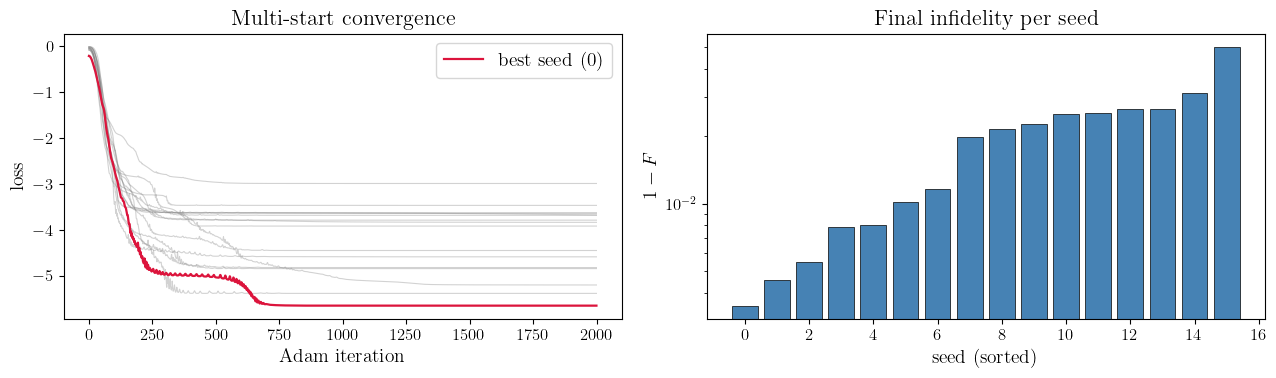

In [9]:
history = jnp.asarray(res_ecd.adam_history)
seed_fids = jnp.asarray(res_ecd.per_seed_fidelity)
iters = jnp.arange(history.shape[1])

fig, (ax_hist, ax_seeds) = plt.subplots(1, 2, figsize=(13, 4))

for k in range(history.shape[0]):
    ax_hist.plot(iters, history[k], color="gray", alpha=0.35, linewidth=0.8)
ax_hist.plot(
    iters,
    history[res_ecd.best_seed],
    color="crimson",
    linewidth=1.6,
    label=f"best seed ({res_ecd.best_seed})",
)
ax_hist.set_xlabel("Adam iteration")
ax_hist.set_ylabel("loss")
ax_hist.set_title("Multi-start convergence")
ax_hist.legend()

sorted_infid = 1 - jnp.sort(seed_fids)[::-1]
ax_seeds.bar(
    jnp.arange(sorted_infid.size),
    sorted_infid,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5,
)
ax_seeds.set_yscale("log")
ax_seeds.set_xlabel("seed (sorted)")
ax_seeds.set_ylabel(r"$1 - F$")
ax_seeds.set_title("Final infidelity per seed")

fig.tight_layout()
plt.show()

## Achieved state vs. target

For the ECD set with `qubit_target="ground"`, the fidelity is $|\braket{\psi_t | \psi_g}|^2$: a high value certifies both that the cavity reached the target *and* that the qubit returned to $\ket{g}$ disentangled. `final_qarray()` hands back that $\ket{g}$ block, renormalized.

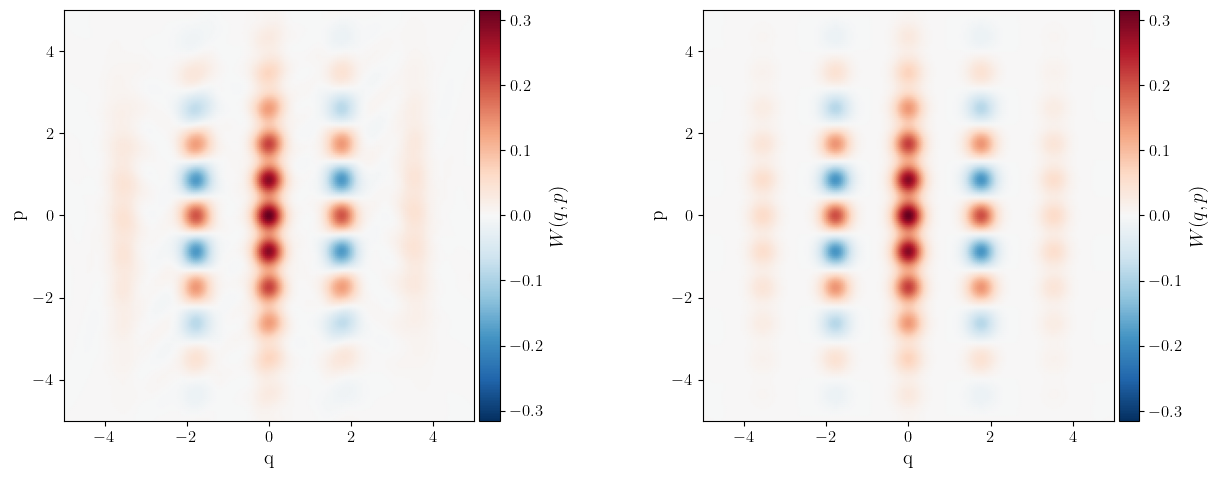

In [16]:
psi_final = res_ecd.final_qarray()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_wigner(psi_final.data, x_bound=5, y_bound=5, ax=axes[0])
plot_wigner(gkp_0, x_bound=5, y_bound=5, ax=axes[1])
fig.tight_layout()
plt.show()

Photon-number distributions are the quicker check on truncation health: population piling up near $n = n_{\text{fock}}$ means the leakage penalty was too weak, `n_leak` too small, or `n_fock` simply too tight for the displacements the optimizer wants to use.

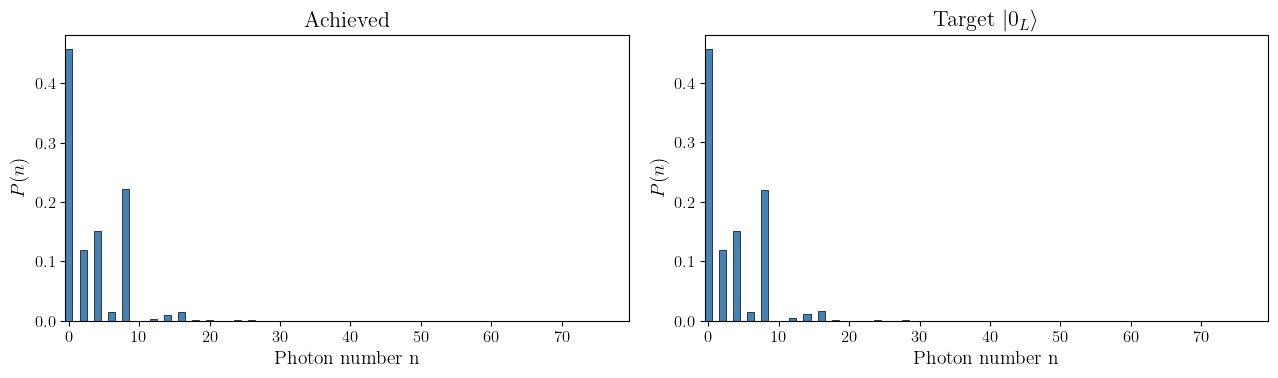

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_photon_number(psi_final.data, ax=axes[0], title="Achieved")
plot_photon_number(gkp_0, ax=axes[1], title=r"Target $\ket{0_L}$")
fig.tight_layout()
plt.show()

## Layer-by-layer Wigner functions

`sequence_history(result, psi_init)` re-runs the optimized circuit and returns the state after *every* gate, reading the ansatz options back out of `result.config`. The leading axis has length `2 * n_gates + 2`, laid out as

```
index 0        : input state
index 1        : after the first rotation (ECD) / first displacement (SNAP)
index 2 + 2i   : after ECD i+1 / SNAP i+1
index 3 + 2i   : after the rotation / displacement that follows it
```

so the ends of complete layers are `range(3, 2 * n_gates + 2, 2)`. The remaining axes are `(K, n_fock)` for SNAP and `(K, 2, n_fock)` for ECD, where the second-to-last axis indexes the qubit block $(\ket{g}, \ket{e})$.

That qubit axis needs care. Mid-circuit the cavity is genuinely entangled with the ancilla, so there is no cavity *ket* to plot — the honest object is the reduced density matrix $\rho_{\text{cav}} = \ket{\psi_g}\bra{\psi_g} + \ket{\psi_e}\bra{\psi_e}$. The helper below returns a `Qarray` either way, so `plot_wigner` handles both gate sets unchanged.

In [ ]:
def frame_to_array(frame):
    """One frame of a sequence_history slice -> array ready for plot_wigner.

    ECD frames are (2, n_fock) qubit blocks and get traced down to a cavity
    density matrix; SNAP frames are plain (n_fock,) kets. Returns a raw JAX
    array rather than a Qarray, so plot_wigner's own coercion handles it.
    """
    arr = jnp.asarray(frame)
    if arr.ndim == 2:  # ECD: trace out the qubit
        rho = arr.T @ arr.conj()
        return rho / jnp.real(jnp.trace(rho))
    return ket(arr)


hist = jnp.asarray(sequence_history(res_ecd, vac))
pair = 0  # which (init, target) pair to follow; only one here
idxs = [0] + list(range(3, 2 * res_ecd.n_gates + 2, 2))

n_col = 5
n_row = -(-len(idxs) // n_col)  # ceiling division
fig, _ = plt.subplots(n_row, n_col, figsize=(3.4 * n_col, 3.6 * n_row))
axes = fig.axes  # flat, row-major; grabbed before any colorbar axes are added

for ax, i in zip(axes, idxs):
    label = "input" if i == 0 else f"layer {i // 2}"
    plot_wigner(frame_to_array(hist[i][pair]), x_bound=6, y_bound=6,
                ax=ax, title=label, grid_points=120, add_colorbar=False)
for ax in axes[len(idxs):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Read left to right, this is the circuit assembling the GKP lattice: early layers spread the vacuum into a squeezed or cat-like structure, and the later ones interfere those lobes into the grid of alternating peaks. Pair these frames with `utils.wigner_trajectory` and `animation.animate_wigner` if you want a movie instead of a strip.

## Reading out the circuit

`params` is the labelled view of the solution — for the ECD set, the rotation angles $(\theta_i, \phi_i)$, the complex displacements $\beta_i$, their magnitudes, and the per-pair fidelities. This is what you hand to a pulse compiler, and `disp_magnitudes` is the number to check against hardware: the required ECD amplitude sets the gate duration, and large $|\beta|$ is exactly what the `max_disp` penalty exists to discourage.

In [ ]:
p = res_ecd.params
thetas = jnp.asarray(p["thetas"])
phis = jnp.asarray(p["phis"])
betas = jnp.asarray(p["betas"])
disp_mags = jnp.asarray(p["disp_magnitudes"])

print("thetas :", jnp.round(thetas, 3))
print("phis   :", jnp.round(phis, 3))
print("betas  :", [f"{b:.3f}" for b in betas])

fig, ax = plt.subplots(figsize=(9, 3.5))
layers = jnp.arange(1, disp_mags.size + 1)
ax.bar(layers, disp_mags, color="steelblue", edgecolor="black", linewidth=0.5)
ax.axhline(bounds.max_disp, color="crimson", linestyle="--", alpha=0.7,
           label=r"$|\beta|_{\max}$")
ax.set_xlabel("ECD layer")
ax.set_ylabel(r"$|\beta_i|$")
ax.set_xticks(layers)
ax.legend()
fig.tight_layout()
plt.show()

## Warm starts

Passing `params0` replaces the random initialization. A `(n_params,)` vector skips the multi-start entirely and optimizes that single point — the natural way to push an existing solution further with a longer, gentler run. A `(n_seeds, n_params)` array replaces the whole batch, which is useful for seeding a deeper circuit from a shallower solution or for sweeping a target while carrying parameters forward.

Note that `n_seeds` is ignored for a 1D `params0`; the reported seed count becomes 1.

In [ ]:
res_warm = optimize_gate_sequence(
    "ecd",
    12,
    vac,
    gkp_0,
    disp_method="quadrature",
    loss_type="log_infidelity",
    bounds=bounds,
    optimizer=OptimizerConfig(n_adam_iters=1500, peak_lr=0.005, polish_maxiter=2000),
    params0=jnp.asarray(res_ecd.flat_params),
)

print(f"\nbefore: 1 - F = {1 - res_ecd.fidelity:.3e}")
print(f"after : 1 - F = {1 - res_warm.fidelity:.3e}")

## Optimizing a gate, not just a state

Passing `K > 1` state pairs optimizes *one* parameter set for all of them simultaneously, which is how you target a logical gate rather than a single preparation. For the logical $X_L$ we need $\ket{0_L} \to \ket{1_L}$ and $\ket{1_L} \to \ket{0_L}$ under the same circuit.

`batch_reduction` decides how the pairs combine, and the choice is not cosmetic:

- `"mean"` averages the per-pair fidelities. Each pair may be satisfied with its own independent phase, so a "perfect" score does not imply a coherent gate.
- `"coherent"` averages the *overlaps* before squaring, $F = |\overline{\braket{\psi_t | U | \psi_i}}|^2$. This fixes the relative phase between logical basis states and leaves only one global phase free — the right objective for a gate on a subspace.

Since the inputs here are orthonormal and span the logical space, constraining these two pairs coherently determines the action on the whole subspace up to that global phase; adding the $\ket{\pm_L}$ pairs would be redundant. Note also that `"coherent"` requires `qubit_target="ground"` (the default): a traced-out qubit has no well-defined overlap phase, and the module raises rather than silently averaging something meaningless.

In [ ]:
res_x = optimize_gate_sequence(
    "ecd",
    12,
    [gkp_0, gkp_1],  # inputs
    [gkp_1, gkp_0],  # targets: logical X_L
    disp_method="quadrature",
    loss_type="log_infidelity",
    batch_reduction="coherent",
    bounds=bounds,
    optimizer=OptimizerConfig(n_seeds=16, n_adam_iters=2000, seed=3),
)

per_pair = jnp.asarray(res_x.params["per_pair_fidelity"])
print()
print(f"coherent F : {res_x.fidelity:.6f}")
print("per-pair F :", jnp.round(per_pair, 6))

The per-pair fidelities are reported alongside the coherent figure precisely so you can spot the failure mode where both pairs land on their targets individually but with a relative phase error — high per-pair values with a noticeably lower coherent $F$.

In [ ]:
finals = res_x.final_qarray()  # list of Qarrays, one per pair

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (achieved, target, name) in enumerate(
    zip(finals, [gkp_1, gkp_0], [r"1_L", r"0_L"])
):
    plot_wigner(achieved, x_bound=5, y_bound=5, ax=axes[row][0],
                title=rf"$X_L$ output {row + 1}")
    plot_wigner(target, x_bound=5, y_bound=5, ax=axes[row][1],
                title=rf"Target $\ket{{{name}}}$")
fig.tight_layout()
plt.show()

## Checklist

Things worth confirming before believing a number out of this module:

1. **x64 is enabled**, before any array is created. Otherwise fidelities above $\sim 1 - 10^{-6}$ are noise.
2. **The displacement operator is unitary.** Both supplied methods are; the closed-form Fock matrix elements are not, and the module refuses to offer them for that reason.
3. **The truncation holds mid-circuit, not just at the endpoints.** Check `leakage`, check the photon-number tail, and remember that `n_leak` levels are penalized after every displacement.
4. **The seed spread is not suspicious.** Wide spread means add seeds; narrow spread at high infidelity means add depth. The best single seed of sixteen is a very different claim from a converged optimum.
5. **`loss_type="log_infidelity"`** once you are past $F \approx 0.99$.
6. **`batch_reduction="coherent"`** for gates; `"mean"` for independent state preparations.
7. **Fidelities here are ansatz-limited only.** The gates are ideal unitaries. Kerr, finite gate duration, and ancilla decoherence all live in `grape.py`'s world, not this one, so treat these numbers as the ceiling a real device works toward.

For anything the top-level entry point does not expose, `build_sequence(gate_set, n_gates, n_fock, **kwargs)` returns the underlying `GateSequence` directly — its `propagate`, `history`, `overlaps`, `fidelity`, `init`, and `describe` closures are the pieces `optimize_gate_sequence` is assembled from, and they are all jittable and differentiable on their own.